# Evaluación del Agente de Connect-4 (Agente Optimo)

Este notebook contiene la validación experimental y la optimización del agente de Connect-4 propuesto para el proyecto de Fundamentos de Inteligencia Artificial.

## 1. Configuración Inicial
Añadimos la ruta del proyecto para poder importar los módulos necesarios.

In [7]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import importlib.util

# Fijar el directorio raíz (como el notebook está en la carpeta tournament, es el current working directory)
tournament_root = os.path.abspath(os.getcwd())
if tournament_root not in sys.path:
    sys.path.append(tournament_root)

from connect4.connect_state import ConnectState
from connect4.policy import Policy
from groups.AgenteOptimo.policy import AgenteOptimo

# Importar FVMC de Group A
group_a_path = os.path.join(tournament_root, "groups", "Group A", "policy.py")
spec_a = importlib.util.spec_from_file_location("FVMCPolicy", group_a_path)
module_a = importlib.util.module_from_spec(spec_a)
spec_a.loader.exec_module(module_a)
ProfesorFVMC = module_a.ProfesorFVMC

# Importar ADP de Group B
group_b_path = os.path.join(tournament_root, "groups", "Group B", "policy.py")
spec_b = importlib.util.spec_from_file_location("ADPPolicy", group_b_path)
module_b = importlib.util.module_from_spec(spec_b)
spec_b.loader.exec_module(module_b)
Connect4ADPAgent = module_b.Connect4ADPAgent

sns.set_theme(style="whitegrid")

## 2. Función de Evaluación (Torneo Rápido)
Creamos una función que permite enfrentar a dos agentes $N$ veces y obtener el porcentaje de victorias, empates y derrotas.

In [8]:
def evaluate_agents(agent1, agent2, n_games=20):
    wins_1 = 0
    wins_2 = 0
    draws = 0
    
    for i in range(n_games):
        # Alternar quién empieza
        first_player_dist = 1.0 if i % 2 == 0 else 0.0
        
        agent1.mount()
        agent2.mount()
        
        # Simulación directa
        state = ConnectState()
        agent1_is_red = (i % 2 == 0)
        
        while not state.is_final():
            if state.player == -1: # Red juega
                action = agent1.act(state.board) if agent1_is_red else agent2.act(state.board)
            else: # Yellow juega
                action = agent2.act(state.board) if agent1_is_red else agent1.act(state.board)
            
            state = state.transition(int(action))
            
        winner = state.get_winner()
        if winner == -1:
            if agent1_is_red: wins_1 += 1
            else: wins_2 += 1
        elif winner == 1:
            if not agent1_is_red: wins_1 += 1
            else: wins_2 += 1
        else:
            draws += 1
            
    return wins_1 / n_games, wins_2 / n_games, draws / n_games

## 3. Torneo Final: Batalla a 3 Bandas
Enfrentamos a nuestros 3 agentes top:
1. **AgenteOptimo:** Algoritmo MCTS (Monte Carlo Tree Search) optimizado con tabla de transposición y heurísticas.
2. **Group A (ProfesorFVMC):** Algoritmo First Visit Monte Carlo con persistencia de memoria y tabla Q pre-entrenada.
3. **Group B (Connect4ADPAgent):** Algoritmo Adaptive Dynamic Programming (ADP) con Reward Shaping.

Cada par se enfrentará en una serie de juegos para ver quién es el maestro definitivo de Connect-4.

🏆 INICIANDO GRAN TORNEO DE IA: CONNECT-4 🏆

⚔️  [MCTS (AgenteOptimo)] vs [FVMC (Group A)]
Jugando 20 partidas...
✅ Resultado Final: MCTS (AgenteOptimo) ganó 16, FVMC (Group A) ganó 4, Empates: 0


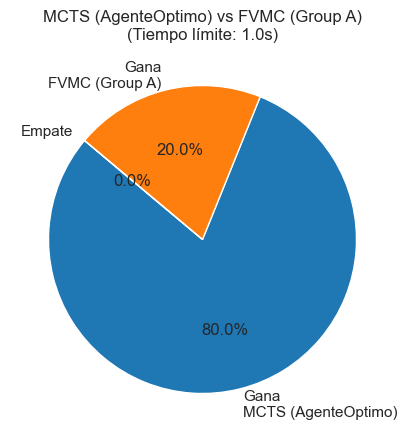


⚔️  [MCTS (AgenteOptimo)] vs [ADP (Group B)]
Jugando 20 partidas...
✅ Resultado Final: MCTS (AgenteOptimo) ganó 20, ADP (Group B) ganó 0, Empates: 0


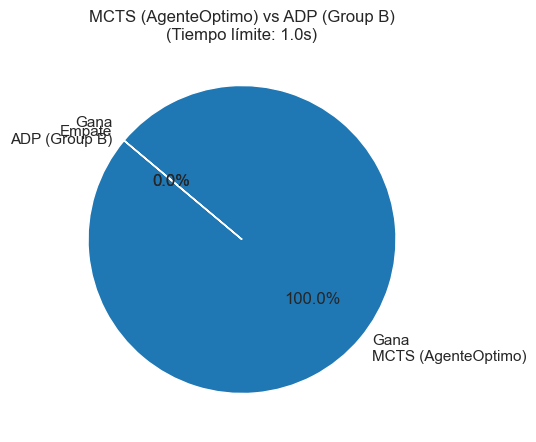


⚔️  [FVMC (Group A)] vs [ADP (Group B)]
Jugando 20 partidas...
✅ Resultado Final: FVMC (Group A) ganó 20, ADP (Group B) ganó 0, Empates: 0


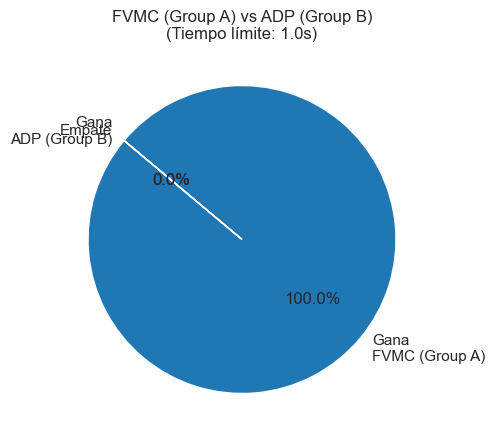

In [9]:
# Configuraciones del torneo
tiempo_limite = 1.0 # Segundos por turno (reducido a 1.0 para que el notebook no demore horas)
n_juegos = 20        # Cantidad de partidas por enfrentamiento (se recomienda 4 o 6)

# Instanciamos los nuevos agentes
agente_mcts = AgenteOptimo(num_simulations=400, heuristics_enabled=True, max_time=tiempo_limite)
agente_fvmc = ProfesorFVMC(max_time=tiempo_limite)
agente_adp = Connect4ADPAgent(max_time=tiempo_limite)

enfrentamientos = [
    ("MCTS (AgenteOptimo)", agente_mcts, "FVMC (Group A)", agente_fvmc),
    ("MCTS (AgenteOptimo)", agente_mcts, "ADP (Group B)", agente_adp),
    ("FVMC (Group A)", agente_fvmc, "ADP (Group B)", agente_adp)
]

print("==========================================================")
print("🏆 INICIANDO GRAN TORNEO DE IA: CONNECT-4 🏆")
print("==========================================================")

for nombre_a, a, nombre_b, b in enfrentamientos:
    print(f"\n⚔️  [{nombre_a}] vs [{nombre_b}]")
    print(f"Jugando {n_juegos} partidas...")
    
    w_a, w_b, empates = evaluate_agents(a, b, n_games=n_juegos)
    
    print(f"✅ Resultado Final: {nombre_a} ganó {w_a*n_juegos:.0f}, {nombre_b} ganó {w_b*n_juegos:.0f}, Empates: {empates*n_juegos:.0f}")
    
    # Graficar
    labels = [f'Gana\n{nombre_a}', f'Gana\n{nombre_b}', 'Empate']
    sizes = [w_a, w_b, empates]
    colors = ['#1f77b4', '#ff7f0e', '#7f7f7f']
    
    plt.figure(figsize=(5, 5))
    if sum(sizes) > 0:
        plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
        plt.title(f'{nombre_a} vs {nombre_b}\n(Tiempo límite: {tiempo_limite}s)')
        plt.show()